<a href="https://colab.research.google.com/github/gbhav1003/python-1/blob/main/EDA_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset Generation
np.random.seed(42)
n = 200
data = {
    "order_id": range(1001, 1001 + n),
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore", "Chennai"], size=n),
    "category": np.random.choice(["Electronics", "Clothing", "Groceries", "Furniture"], size=n),
    "order_value": np.random.randint(200, 5000, size=n).astype(float),
    "delivery_days": np.random.randint(1, 15, size=n).astype(float),
    "rating": np.random.choice([1, 2, 3, 4, 5, None], size=n)
}

missing_indices_order = np.random.choice(n, size=15, replace=False)
missing_indices_delivery = np.random.choice(n, size=10, replace=False)
data["order_value"][missing_indices_order] = np.nan
data["delivery_days"][missing_indices_delivery] = np.nan
data["order_value"][5] = 95000
data["order_value"][88] = 87000

df = pd.DataFrame(data)

In [4]:
df

,order_id,city,category,order_value,delivery_days,rating
0,1001,Bangalore,Groceries,4191.0,11.0,4
1,1002,Chennai,Furniture,4923.0,12.0,1
2,1003,Mumbai,Groceries,4882.0,13.0,2
3,1004,Bangalore,Electronics,1848.0,13.0,1
4,1005,Bangalore,Furniture,1645.0,12.0,1
...,...,...,...,...,...,...
195,1196,Delhi,Furniture,1768.0,12.0,5
196,1197,Delhi,Furniture,4200.0,5.0,1
197,1198,Chennai,Clothing,2938.0,4.0,4
198,1199,Mumbai,Furniture,3698.0,3.0,2


# Task 1: Inspect & Handle Missing Values

In [5]:
print("--- Task 1 ---")
print(f"Shape of DataFrame: {df.shape}")
print("\nData Types:\n", df.dtypes)
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100
print("\nMissing Values Count:\n", missing_count)
print("\nMissing Values Percentage (%):\n", missing_percent.round(2))

--- Task 1 ---
Shape of DataFrame: (200, 6)

Data Types:
 order_id           int64
city              object
category          object
order_value      float64
delivery_days    float64
rating            object
dtype: object

Missing Values Count:
 order_id          0
city              0
category          0
order_value      14
delivery_days    10
rating           32
dtype: int64

Missing Values Percentage (%):
 order_id          0.0
city              0.0
category          0.0
order_value       7.0
delivery_days     5.0
rating           16.0
dtype: float64


# Task 2: Summarize & Visualize


--- Task 2 ---

Numerical Summary:
           order_id   order_value  delivery_days
count   200.000000    186.000000     190.000000
mean   1100.500000   3707.134409       7.810526
std      57.879185   9238.438378       4.075465
min    1001.000000    204.000000       1.000000
25%    1050.750000   1512.000000       4.000000
50%    1100.500000   2934.000000       8.000000
75%    1150.250000   3987.500000      12.000000
max    1200.000000  95000.000000      14.000000


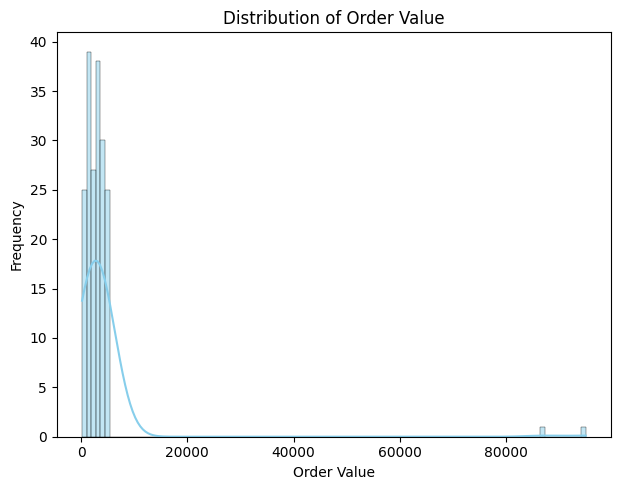

In [7]:
print("\n--- Task 2 ---")
summary = df.describe()
print("\nNumerical Summary:\n", summary)

# Visuals
plt.figure(figsize=(12, 5))

# Order Value Histogram
plt.subplot(1, 2, 1)
sns.histplot(df['order_value'].dropna(), kde=True, color='skyblue')
plt.title('Distribution of Order Value')
plt.xlabel('Order Value')
plt.ylabel('Frequency')


plt.tight_layout()
plt.show()

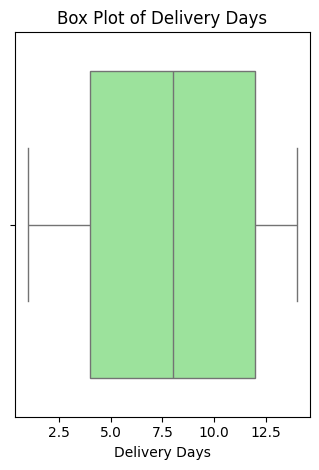

In [8]:
# Delivery Days Box Plot
plt.subplot(1, 2, 2)
sns.boxplot(x=df['delivery_days'], color='lightgreen')
plt.title('Box Plot of Delivery Days')
plt.xlabel('Delivery Days')

plt.tight_layout()
plt.show()

# Task 3: Correlation Analysis


--- Task 3 ---

Correlation Matrix:
                order_id  order_value  delivery_days    rating
order_id       1.000000    -0.095503       0.004858  0.043980
order_value   -0.095503     1.000000       0.141660 -0.059572
delivery_days  0.004858     0.141660       1.000000 -0.083691
rating         0.043980    -0.059572      -0.083691  1.000000


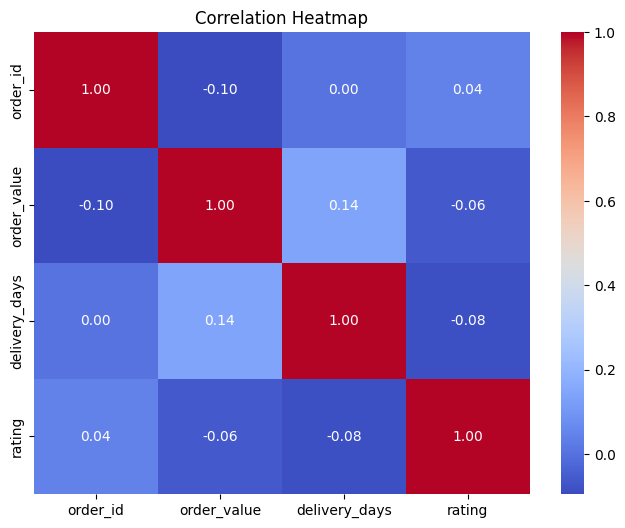

In [9]:
print("\n--- Task 3 ---")
# Drop non-numeric for correlation and handle Rating being object/float mix
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
corr_matrix = df.corr(numeric_only=True)
print("\nCorrelation Matrix:\n", corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()